# 06 — Physical observables across the six production runs

The six full ladders of `05_parallel_axes` were not only timings: each annealed
**4 states x 100 replicas** over 200 temperature points and recorded every
observable. This notebook reads that physics back.

The six runs differ **only** in how the same 400 chains were handed to the
hardware — `BP + replicas` or `BP + replicas + states`, on 1, 2 or 4 H100. The
Hamiltonian, the bipartite update, the temperature ladder and the replica count
are identical. **So the six curves for a given state should lie on top of each
other**, and anything that does not is a bug in the parallelisation rather than
physics.

They are plotted **side by side, never overlaid**: a row of six panels per
observable, with a shared y-axis so the comparison is by eye and not by legend.

**One correction this notebook had to make.** The reduction saved with each run
averages over *all* 400 chains, and in the `both` grouping those 400 carry four
different parameter sets — an average across states is not a physical quantity.
The curves here are recomputed from the raw per-chain accumulators, sliced into
the four 100-chain blocks. The chain ordering is the same in both groupings, so
one slice expression serves for all six runs.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

ANCHOR = "physics_by_state.npz"
def find_results():
    for p in (pathlib.Path("results"),
              pathlib.Path("notebooks/simulation/results"),
              pathlib.Path("/kaggle/input/nanodisk-timing-results")):
        if (p / ANCHOR).exists():
            return p
    root = pathlib.Path("/kaggle/input")
    if root.exists():
        hit = next(root.glob(f"**/{ANCHOR}"), None)
        if hit:
            return hit.parent
        raise FileNotFoundError(
            f"{ANCHOR} not found. Mounted: {[p.name for p in root.iterdir()]}")
    raise FileNotFoundError(ANCHOR)

RES = find_results(); print("reading from", RES)
Z = np.load(RES / ANCHOR, allow_pickle=True)
T, TSNAP = Z["T"], Z["Tsnap"]
STATES = [str(s) for s in Z["states"]]
RUNS = [str(r) for r in Z["runs"]]
THETA = {json.loads(t)["name"]: json.loads(t) for t in Z["thetas"]}
LABEL = {r: r.replace("axl_", "").replace("_", " ").replace("both", "repl+states")
         for r in RUNS}
get = lambda run, st, k: Z[f"m|{run}|{st}|{k}"]

print(f"{len(RUNS)} runs x {len(STATES)} states, {len(T)} temperature points\n")
for st in STATES:
    t = THETA[st]
    print(f"  {st:9s} Kan1={t['Kan1']:.3f}  KanS={t['KanS']:.3f}  "
          f"Hex={t['Hex']:.3f}  KDM={t['KDM']:.3f}")
print("\nruns:", ", ".join(LABEL[r] for r in RUNS))

reading from results
6 runs x 4 states, 200 temperature points

  uniform   Kan1=0.287  KanS=0.000  Hex=0.769  KDM=0.654
  helical   Kan1=0.259  KanS=0.000  Hex=0.093  KDM=1.025
  points    Kan1=0.278  KanS=0.000  Hex=0.389  KDM=1.000
  lines     Kan1=0.508  KanS=0.000  Hex=0.022  KDM=0.512

runs: replicas 1gpu, replicas 2gpu, replicas 4gpu, repl+states 1gpu, repl+states 2gpu, repl+states 4gpu


## Do the six agree?

Before plotting 144 panels, one number: the largest relative spread across the
six runs, per observable and state. If the parallelisation is sound this is at
the level of Monte Carlo noise between independent seeds, not a systematic gap.

In [2]:
OBS = ["E", "M", "Mz", "Cv", "chi", "Q"]
print(f"{'state':10s}" + "".join(f"{o:>12s}" for o in OBS))
print("-" * (10 + 12 * len(OBS)))
worst = {}
for st in STATES:
    row = []
    for o in OBS:
        A = np.array([get(r, st, o) for r in RUNS])          # (6, 200)
        scale = np.abs(A).mean() + 1e-12
        spread = (A.max(0) - A.min(0)).max() / scale          # worst point
        row.append(spread); worst[(st, o)] = spread
    print(f"{st:10s}" + "".join(f"{v*100:11.2f}%" for v in row))
print("\nspread = (max - min across the six runs) at the worst temperature,")
print("relative to the mean magnitude of that observable.")

state                E           M          Mz          Cv         chi           Q
----------------------------------------------------------------------------------
uniform          0.02%       0.02%       0.02%       6.07%       3.28%       5.07%
helical          0.07%       1.80%       1.88%       8.15%      13.15%      15.75%
points           0.04%       0.29%       0.29%       7.24%      18.70%       2.52%
lines            0.05%       9.46%      10.32%       7.98%      25.89%      34.66%

spread = (max - min across the six runs) at the worst temperature,
relative to the mean magnitude of that observable.


## One figure per state: six panels per observable

Rows are observables, columns are runs. Each row shares its y-axis, so a curve
that sits differently is visibly different rather than differently scaled.

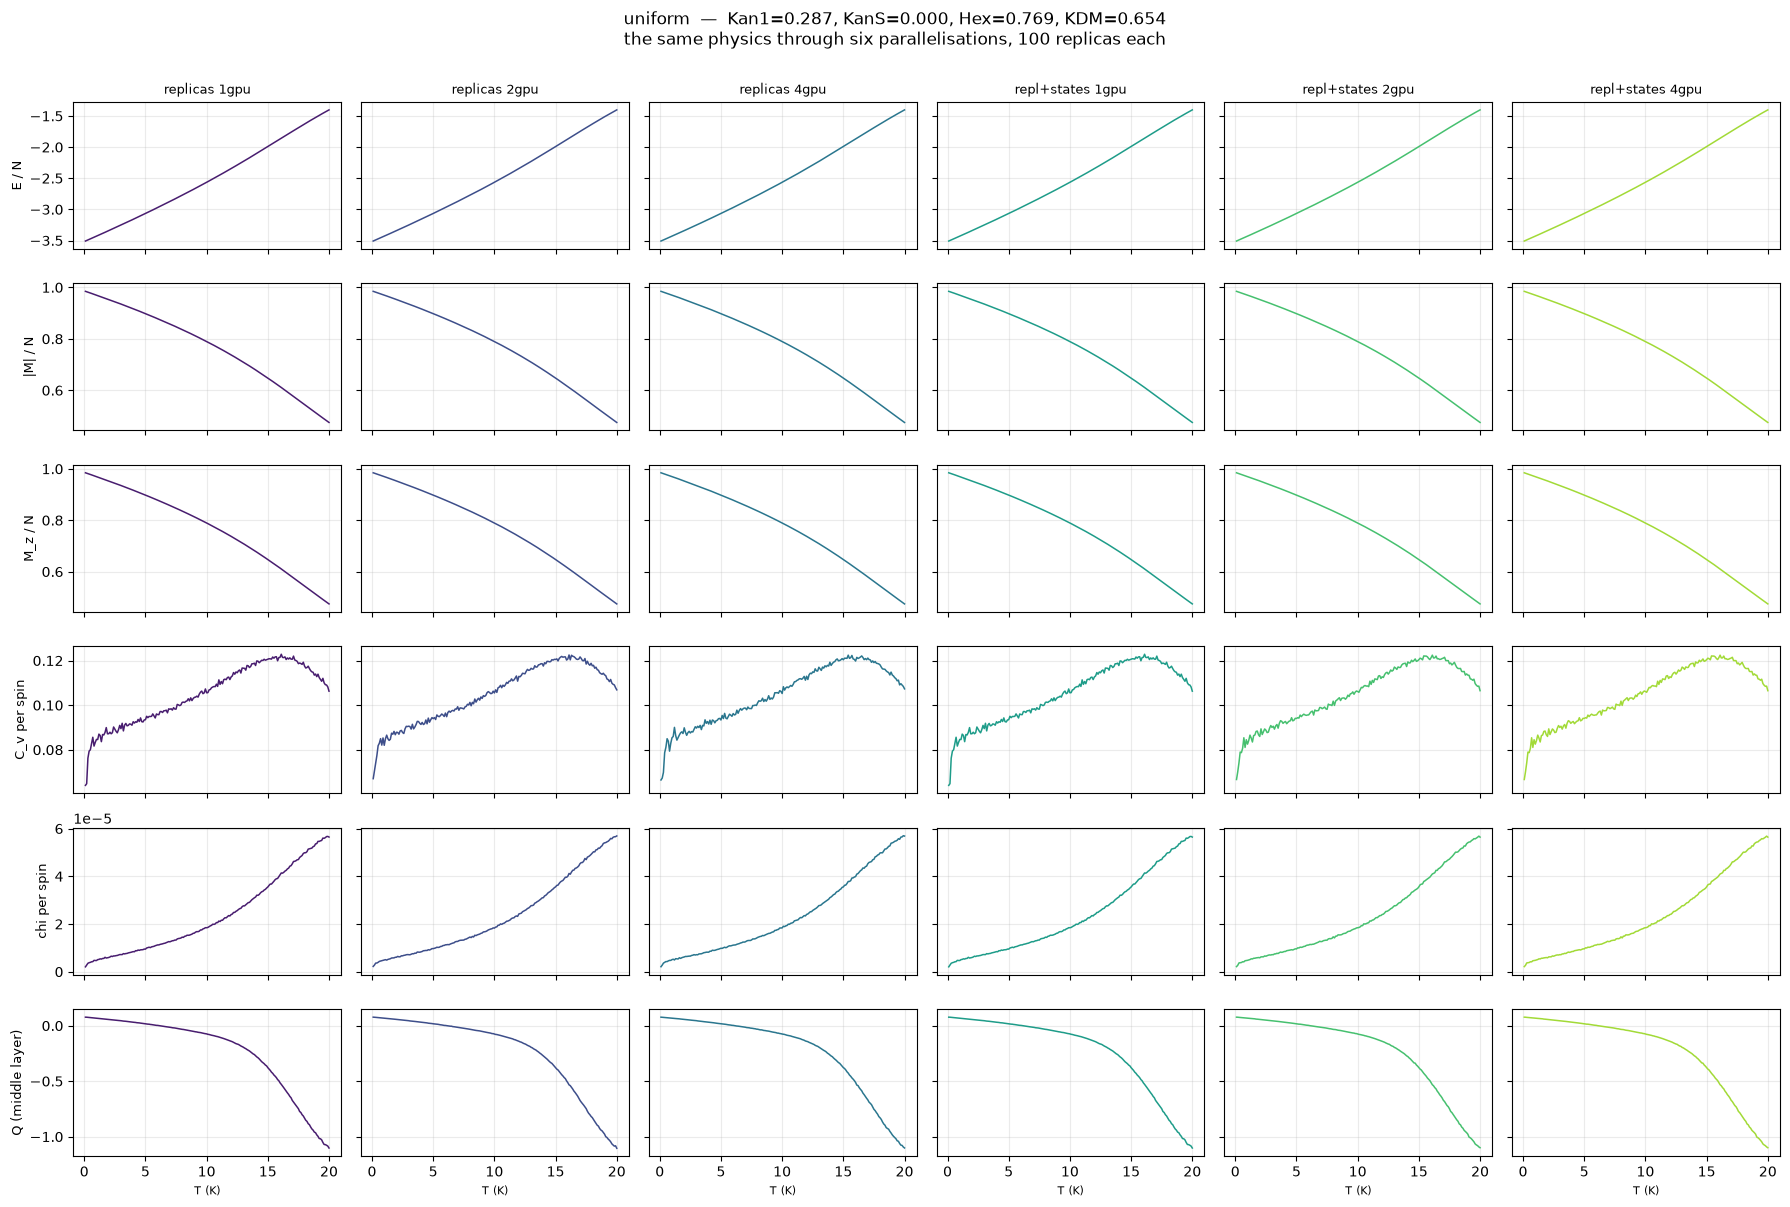

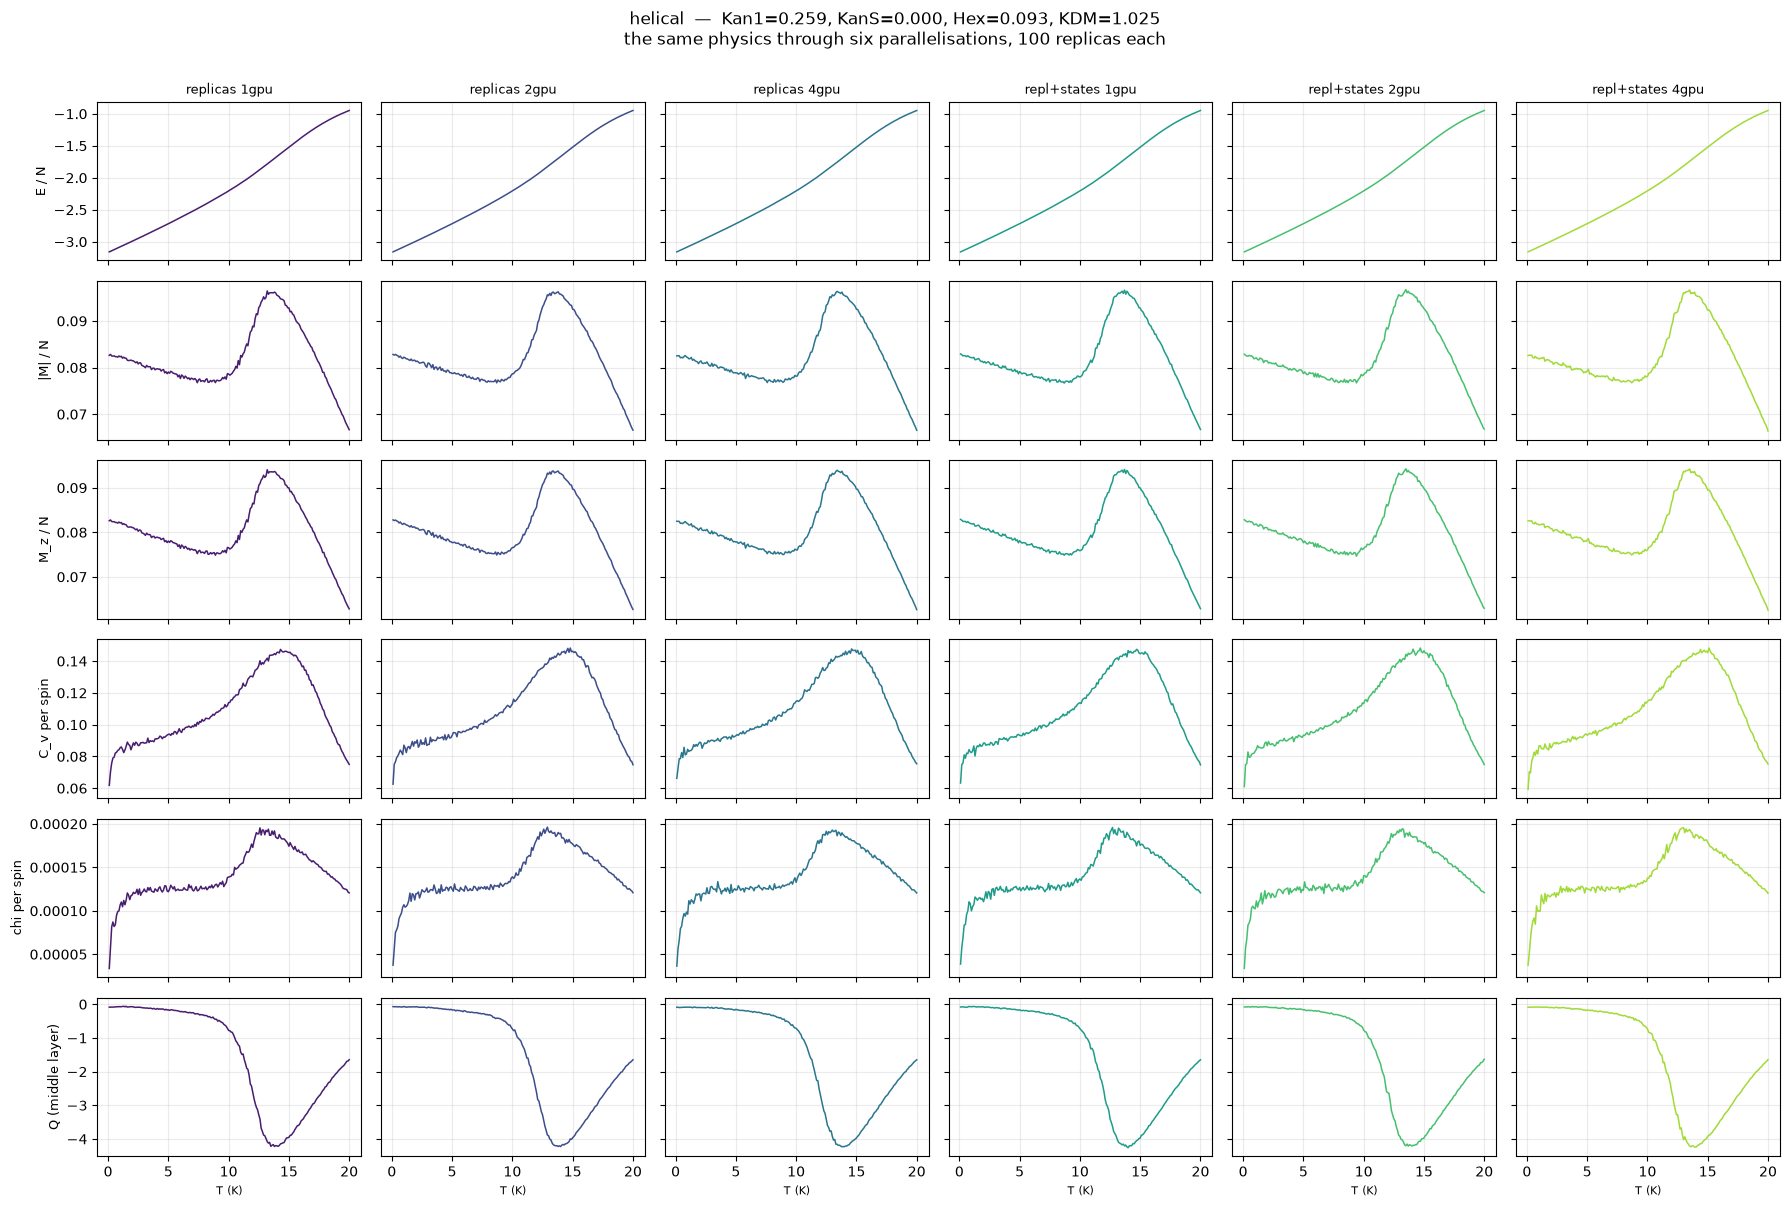

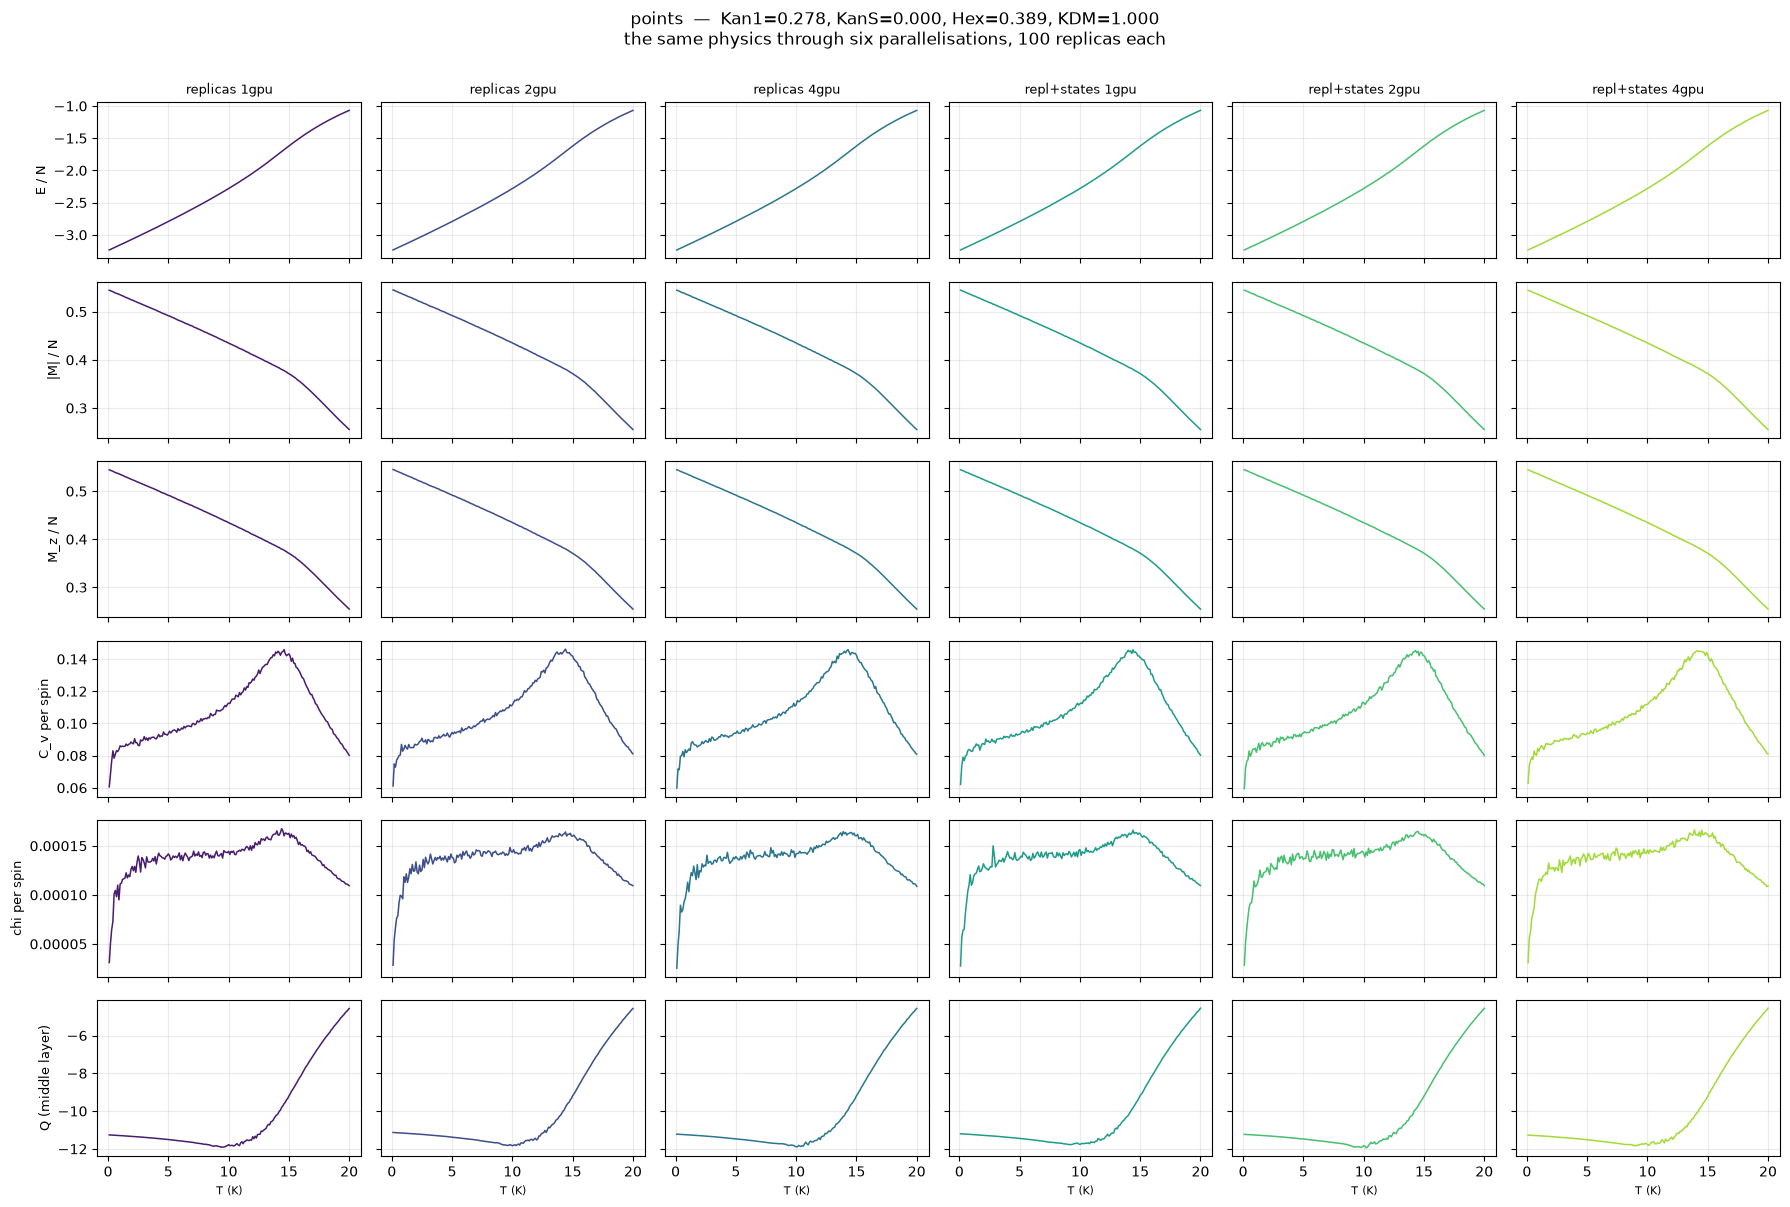

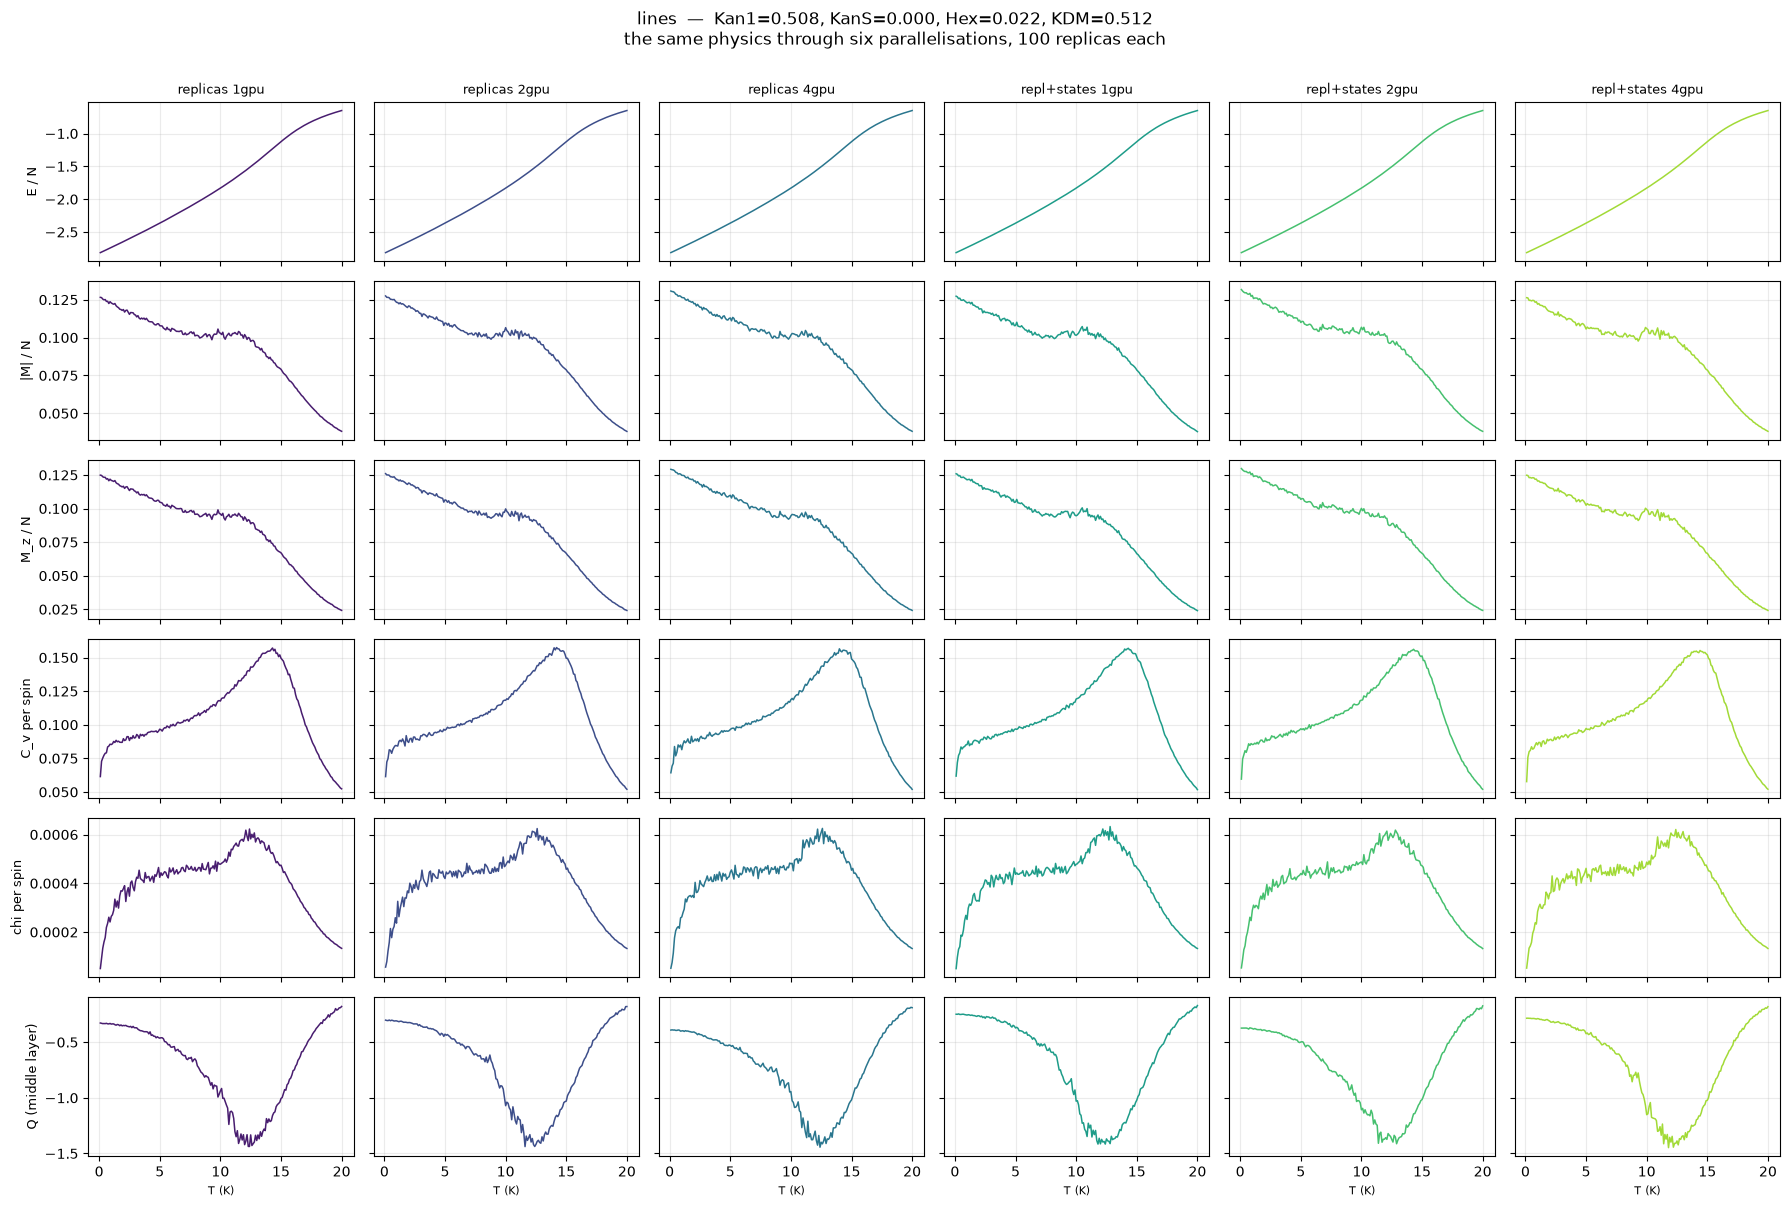

In [3]:
COL = plt.cm.viridis(np.linspace(0.08, 0.86, len(RUNS)))
UNITS = {"E": "E / N", "M": "|M| / N", "Mz": "M_z / N",
         "Cv": "C_v per spin", "chi": "chi per spin", "Q": "Q (middle layer)"}

for st in STATES:
    fig, axes = plt.subplots(len(OBS), len(RUNS),
                             figsize=(3.0 * len(RUNS), 2.0 * len(OBS)),
                             sharex=True, squeeze=False)
    for i, o in enumerate(OBS):
        A = np.array([get(r, st, o) for r in RUNS])
        lo, hi = A.min(), A.max()
        pad = 0.06 * (hi - lo + 1e-12)
        for j, r in enumerate(RUNS):
            ax = axes[i][j]
            ax.plot(T, A[j], lw=1.1, color=COL[j])
            ax.set_ylim(lo - pad, hi + pad)
            ax.grid(alpha=0.25)
            if i == 0:
                ax.set_title(LABEL[r], fontsize=9)
            if j == 0:
                ax.set_ylabel(UNITS[o], fontsize=9)
            else:
                ax.set_yticklabels([])
            if i == len(OBS) - 1:
                ax.set_xlabel("T (K)", fontsize=8)
    t = THETA[st]
    fig.suptitle(f"{st}  —  Kan1={t['Kan1']:.3f}, KanS={t['KanS']:.3f}, "
                 f"Hex={t['Hex']:.3f}, KDM={t['KDM']:.3f}\n"
                 f"the same physics through six parallelisations, "
                 f"100 replicas each", y=1.002, fontsize=12)
    fig.tight_layout(); plt.show()

## The state transition

Middle-layer $s_z$ along the anneal, from 20 K down to 0.1 K. This is the same
view as `01_validation_gpu_vs_prof_dario.ipynb`, here across the runs instead of
against the reference.

**Only a subset of runs carries every state.** The engine snapshots one replica
per launch, so the `replicas` grouping — four launches, one per state — has all
four, while `repl+states` is a single launch and snapshots chain 0 only, which
is `uniform`. That is a property of what was recorded, not of what was computed:
all four states were annealed in every run.

  uniform   transition recorded in: repl+states 1gpu, repl+states 2gpu, repl+states 4gpu, replicas 1gpu, replicas 2gpu, replicas 4gpu
  helical   transition recorded in: replicas 1gpu, replicas 2gpu, replicas 4gpu
  points    transition recorded in: replicas 1gpu, replicas 2gpu, replicas 4gpu
  lines     transition recorded in: replicas 1gpu, replicas 2gpu, replicas 4gpu


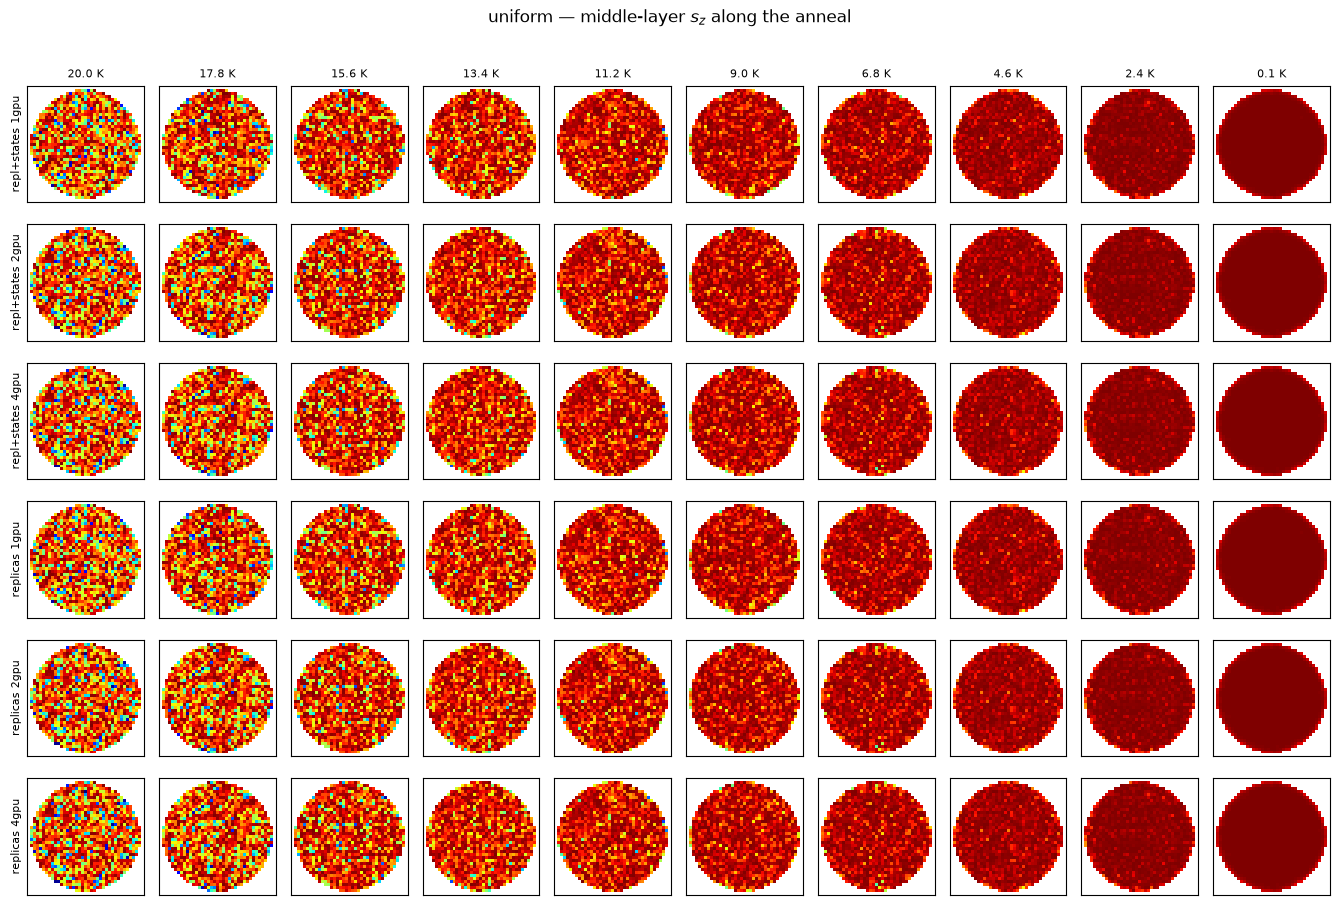

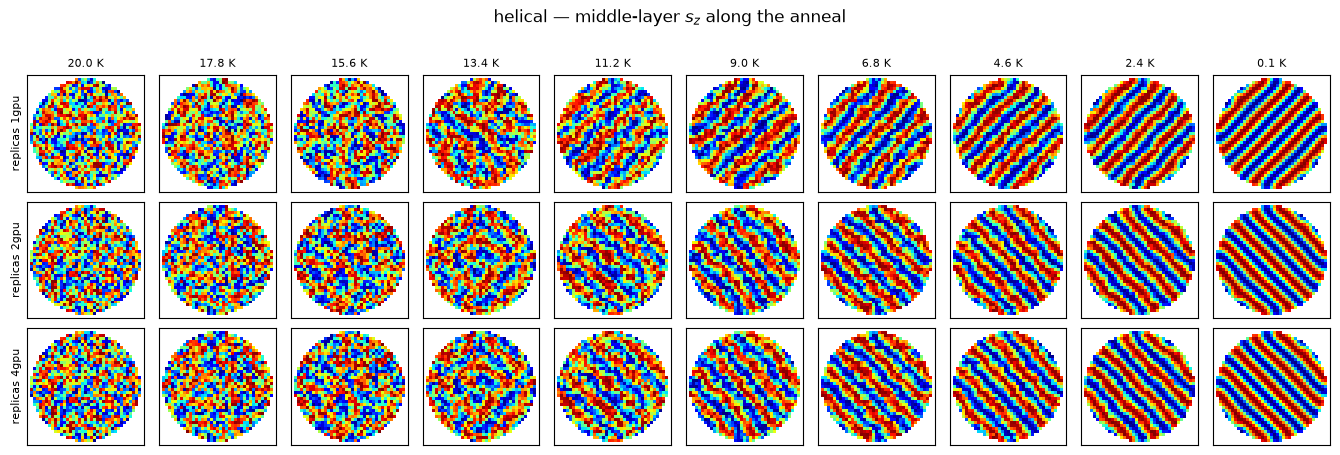

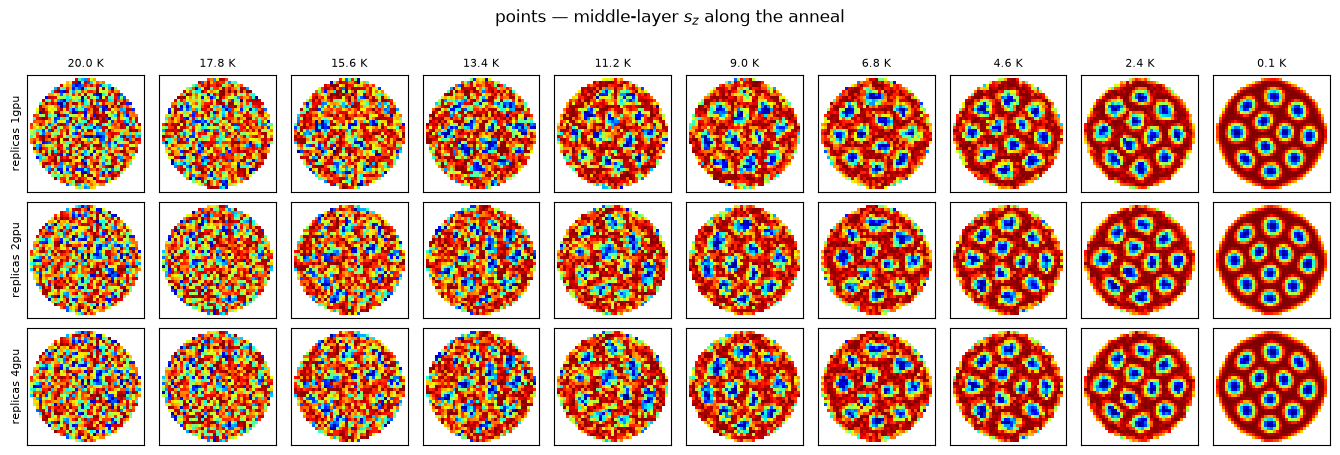

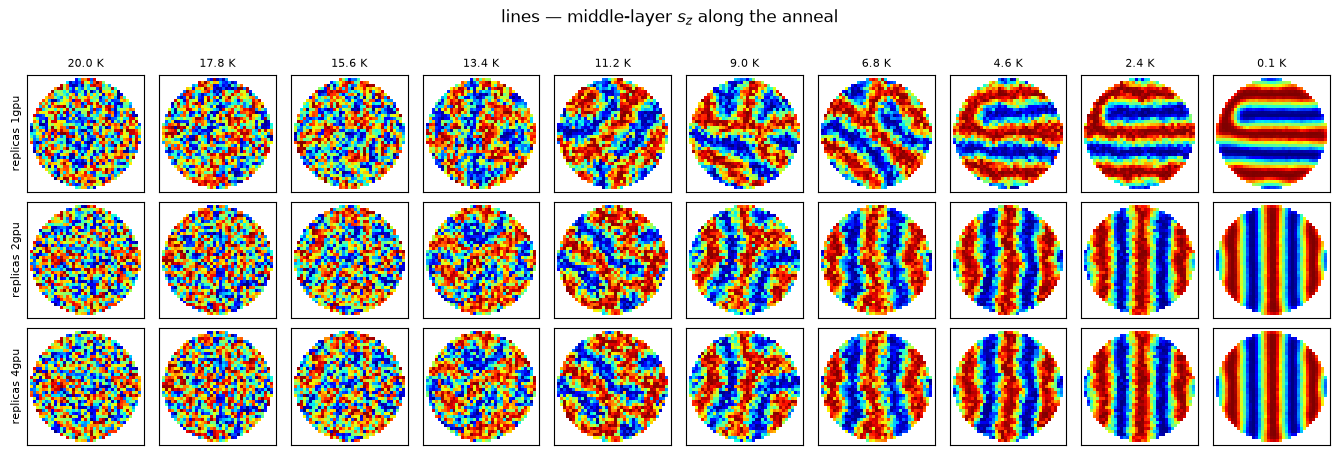

In [4]:
have = sorted({tuple(k.split("|")[1:]) for k in Z.files if k.startswith("s|")})
by_state = {st: [r for r, s in have if s == st] for st in STATES}
for st in STATES:
    print(f"  {st:9s} transition recorded in: "
          + (", ".join(LABEL[r] for r in by_state[st]) or "none"))

MASK = None
for st in STATES:
    runs = by_state[st]
    if not runs:
        continue
    fig, axes = plt.subplots(len(runs), len(TSNAP),
                             figsize=(1.35 * len(TSNAP), 1.5 * len(runs)),
                             squeeze=False)
    for i, r in enumerate(runs):
        strip = np.asarray(Z[f"s|{r}|{st}"], dtype=np.float32)
        if MASK is None:
            # Outside the disk the spins are identically zero; blanking them
            # keeps the colour scale on the physics instead of the padding.
            MASK = np.where(np.abs(strip).sum(0) > 0, 1.0, np.nan)
        for j in range(len(TSNAP)):
            ax = axes[i][j]
            ax.imshow(strip[j] * MASK, origin="lower", cmap="jet",
                      vmin=-1, vmax=1, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0:
                ax.set_title(f"{TSNAP[j]:.1f} K", fontsize=8)
            if j == 0:
                ax.set_ylabel(LABEL[r], fontsize=8)
    fig.suptitle(f"{st} — middle-layer $s_z$ along the anneal", y=1.01,
                 fontsize=12)
    fig.tight_layout(); plt.show()

## Declared limits

- **The curves are recomputed, not the ones saved with the runs.** Those averaged
  over all 400 chains, which mixes four parameter sets in the `repl+states`
  grouping. Everything here is sliced per state from the raw accumulators.
- **`C_v` and `chi` are variances**, accumulated about a reference taken once per
  temperature. Without that subtraction they come out negative in float32 — the
  totals are large enough that one ulp exceeds the variance itself.
- **`Q` is the Berg–Lüscher charge of the middle layer only**, not of the whole
  disk, and it is averaged over the 100 replicas of that state. A single replica
  takes integer-ish values; the mean does not.
- **Transitions exist for every state only in the `replicas` runs**, for the
  recording reason above.
- The four states are the medians of four phase clusters in the released
  dataset. Agreement here is between *our own* runs; the check against Prof.
  Darío's released states is `01_validation_gpu_vs_prof_dario.ipynb`.